In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from src.data import pull_statcast
from src.features import build_features, get_feature_cols
from src.arsenal import compute_arsenal
import config

In [ ]:
df = pull_statcast(config.SEASON, override_cache_path="../data/statcast_2025.parquet")

# maybe want to compute arsenal from previous season's data instead
arsenal = compute_arsenal(df)

df = build_features(df, arsenal)
feature_cols = get_feature_cols(df, arsenal)

X = df[feature_cols]
y = df["pitch_type_idx"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_SEED
)

Loading cached data from ../data/statcast_2025.parquet


In [4]:
model = XGBClassifier(**config.XGB_PARAMS)
model.fit(X_train, y_train)
print(f"Train accuracy: {model.score(X_train, y_train):.4f}")

Train accuracy: 0.4831


In [5]:
print(f"Test accuracy: {model.score(X_test, y_test):.4f}")

Test accuracy: 0.4673


Could be better but for something that took 2 minutes to train, not bad.

In [8]:
import joblib
joblib.dump(model, f"../{config.MODEL_DIR}/xgb_pitch_predictor.pkl")

['../models/xgb_pitch_predictor.pkl']

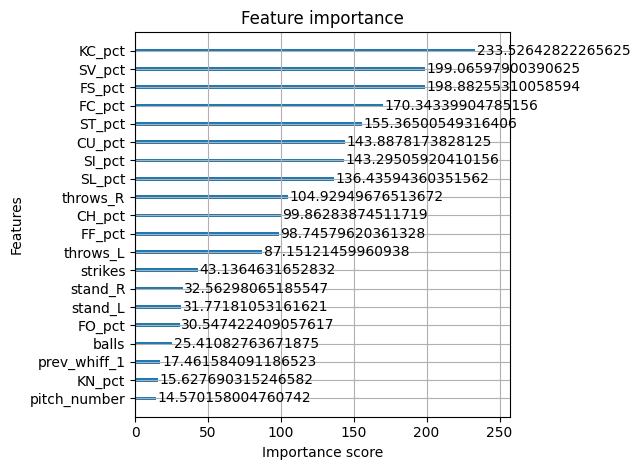

In [6]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=20, importance_type="gain")
plt.tight_layout()
plt.show()

Nice to see that it's weighing arsenal pretty heavily. Naturally that should be the #1 indicator of what a particular pitcher will throw next.

In [19]:
import numpy as np
import pandas as pd

probs = model.predict_proba(X_test)
predicted_dist = probs.mean(axis=0)
actual_dist = np.bincount(y_test, minlength=len(config.PITCH_TO_IDX)) / len(y_test)

idx_to_pitch = {v: k for k, v in config.PITCH_TO_IDX.items()}

dist_df = pd.DataFrame({
    "pitch_type": [idx_to_pitch[i] for i in range(len(predicted_dist))],
    "predicted": predicted_dist,
    "actual": actual_dist,
})
print(dist_df.sort_values("actual", ascending=False))

   pitch_type  predicted    actual
0          FF   0.319444  0.320382
1          SI   0.155672  0.155099
2          SL   0.144181  0.144138
3          CH   0.104006  0.102890
4          ST   0.076395  0.077048
5          FC   0.075168  0.075235
6          CU   0.067547  0.067144
7          FS   0.033296  0.033217
8          KC   0.017878  0.018432
9          SV   0.004894  0.005099
10         FO   0.001171  0.001179
11         KN   0.000142  0.000136


The model is bang on in terms of the distribution, which is encouraging.

In [20]:
results = X_test.copy()
results["y_true"] = y_test.values
results["y_pred"] = model.predict(X_test)
results["correct"] = (results["y_true"] == results["y_pred"]).astype(int)

count_acc = (
    results.groupby(["balls", "strikes"])["correct"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "accuracy", "count": "n_pitches"})
    .round(3)
)
print(count_acc)

               accuracy  n_pitches
balls strikes                     
0     0           0.470      37644
      1           0.433      19354
      2           0.474       9956
1     0           0.479      14207
      1           0.422      14672
      2           0.448      14270
2     0           0.542       4760
      1           0.472       7559
      2           0.441      12273
3     0           0.794       1520
      1           0.595       3091
      2           0.510       7394


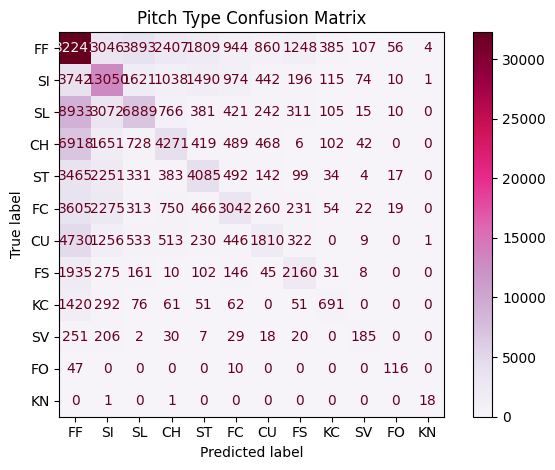

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

pitch_labels = [k for k, v in sorted(config.PITCH_TO_IDX.items(), key=lambda x: x[1])]

cm = confusion_matrix(y_test, model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pitch_labels)
disp.plot(cmap="PuRd")
plt.title("Pitch Type Confusion Matrix")
plt.tight_layout()
plt.show()

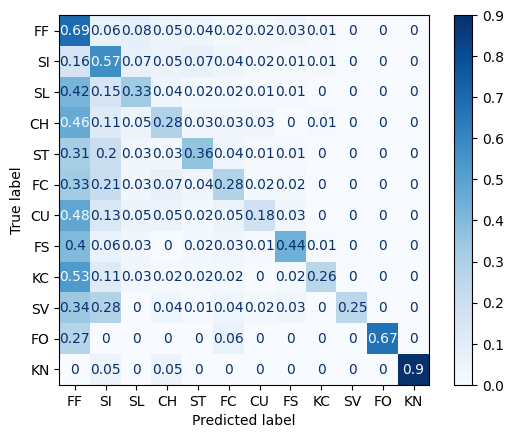

In [29]:
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized.round(2), 
    display_labels=pitch_labels
)
disp.plot(cmap="Blues")